# netoyage des données

In [4]:
import pandas as pd

# ── 1. Chargement ──────────────────────────────────────────────────────────────
df = pd.read_csv("ecg_scg_segment_dataset.csv")
print(f"Shape original : {df.shape}")

# ── 2. Suppression des lignes avec classe manquante ───────────────────────────
df = df.dropna(subset=["classe"])
print(f"Après suppression classe NaN     : {df.shape}")

# ── 3. Suppression beat_index == 0 ────────────────────────────────────────────
# Le premier battement d'un segment n'a pas de RR/HR (pas de battement précédent)
df = df[df["beat_index"] != 0]
print(f"Après suppression beat_index==0  : {df.shape}")

# ── 4. Suppression des NaN sur colonnes ECG et SCG critiques ──────────────────
cols_critiques = ["pr_ms", "qt_ms", "ivrt_ms", "et_ms", "pep_ms", "ivct_ms"]
df = df.dropna(subset=cols_critiques)
print(f"Après suppression NaN ECG/SCG    : {df.shape}")

# ── 5. Encodage de r_detection_method ─────────────────────────────────────────
df["r_detection_method"] = df["r_detection_method"].map({"biosppy": 0, "scipy": 1})

# ── 6. Vérification finale ────────────────────────────────────────────────────
print(f"\nValeurs manquantes restantes : {df.isnull().sum().sum()} (total)")
print(f"\nDistribution des classes :\n{df['classe'].value_counts().sort_index()}")

# ── 7. Sauvegarde (patient_id et segment_name conservés pour le split) ────────
# /!\ On NE supprime PAS patient_id et segment_name — nécessaires pour le split
df.to_csv("ecg_scg_clean.csv", index=False)
print("\n✅ Fichier sauvegardé : ecg_scg_clean.csv")

Shape original : (11017, 42)
Après suppression classe NaN     : (10513, 42)
Après suppression beat_index==0  : (10236, 42)
Après suppression NaN ECG/SCG    : (9435, 42)

Valeurs manquantes restantes : 0 (total)

Distribution des classes :
classe
1.0     653
2.0    1922
3.0    6054
4.0     806
Name: count, dtype: int64

✅ Fichier sauvegardé : ecg_scg_clean.csv


# modele1

Patients uniques  : 42
Segments uniques  : 277
Features          : 39
Distribution classes :
classe
1.0     653
2.0    1922
3.0    6054
4.0     806
Name: count, dtype: int64

Patients train : 33 | Patients test  : 9
Lignes train   : 6318 | Lignes test   : 3117

✅ Aucun patient commun entre train et test

Paramètres entraînables : 80,964

── Entraînement (niveau battement) ──────────────────────
Epoch 010/200 | Loss: 0.0058 | Beat Acc: 0.3381
Epoch 020/200 | Loss: 0.0042 | Beat Acc: 0.2948
Epoch 030/200 | Loss: 0.0021 | Beat Acc: 0.3205

⏹  Early stopping epoch 36 | Meilleure beat acc : 0.3407

═══════════════════════════════════════════════════════
  ACCURACY NIVEAU PATIENT (vote majoritaire) : 0.3333
  (3/9 patients bien classés)
═══════════════════════════════════════════════════════

              precision    recall  f1-score   support

    Classe 1       0.00      0.00      0.00         0
    Classe 2       0.33      0.33      0.33         3
    Classe 3       0.40      0.40      

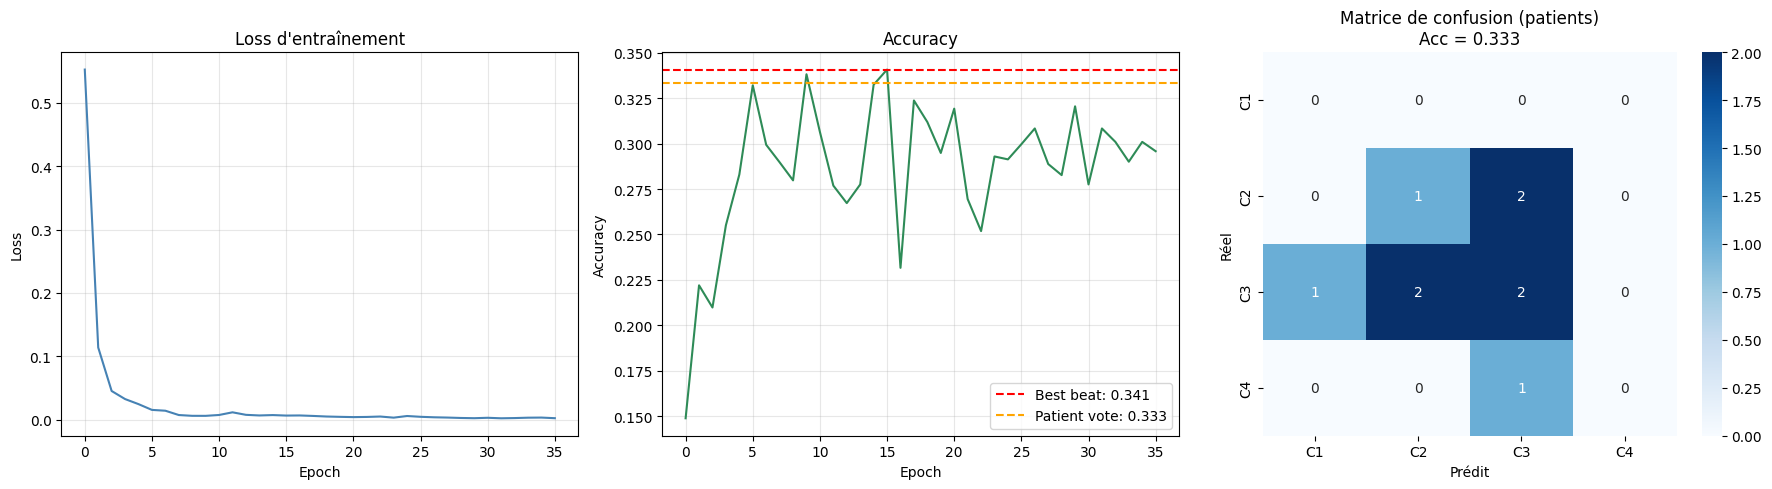


Graphiques sauvegardés : resultats_patient_vote.png


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════════════════
# 1. CHARGEMENT
# ══════════════════════════════════════════════════════════════════════════════
df = pd.read_csv("ecg_scg_clean.csv")

# On a besoin de patient_id et segment_name pour le split → les recharger depuis le CSV brut
# Si ecg_scg_clean.csv ne les contient plus, relancer clean_ecg_scg.py en gardant ces colonnes
# OU recharger les deux fichiers et merger sur l'index
# Ici on suppose que ecg_scg_clean.csv contient encore patient_id et segment_name
# Sinon : relancer le nettoyage avec la ligne ci-dessous ajoutée à la fin (avant le drop)
# df.to_csv("ecg_scg_clean.csv", index=False)  ← sans drop patient_id/segment_name

FEATURE_COLS = [c for c in df.columns if c not in ["classe", "patient_id", "segment_name"]]
TARGET_COL   = "classe"
GROUP_COL    = "patient_id"     # split par patient
SEGMENT_COL  = "segment_name"   # pour le vote majoritaire

print(f"Patients uniques  : {df[GROUP_COL].nunique()}")
print(f"Segments uniques  : {df[SEGMENT_COL].nunique()}")
print(f"Features          : {len(FEATURE_COLS)}")
print(f"Distribution classes :\n{df[TARGET_COL].value_counts().sort_index()}\n")

X       = df[FEATURE_COLS].values
y       = (df[TARGET_COL].astype(int) - 1).values   # 1-4 → 0-3
groups  = df[GROUP_COL].values
segments = df[SEGMENT_COL].values

# ══════════════════════════════════════════════════════════════════════════════
# 2. SPLIT PAR PATIENT (aucun patient ne chevauche train et test)
# ══════════════════════════════════════════════════════════════════════════════
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test     = X[train_idx],        X[test_idx]
y_train, y_test     = y[train_idx],        y[test_idx]
seg_test            = segments[test_idx]   # pour le vote
pat_test            = groups[test_idx]     # pour le vote

print(f"Patients train : {len(np.unique(groups[train_idx]))} | "
      f"Patients test  : {len(np.unique(groups[test_idx]))}")
print(f"Lignes train   : {len(X_train)} | Lignes test   : {len(X_test)}\n")

# Vérification : aucun patient commun
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0, \
    "⚠️ Des patients sont présents dans train ET test !"
print("✅ Aucun patient commun entre train et test\n")

# ══════════════════════════════════════════════════════════════════════════════
# 3. NORMALISATION
# ══════════════════════════════════════════════════════════════════════════════
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ══════════════════════════════════════════════════════════════════════════════
# 4. TENSEURS + DATALOADERS
# ══════════════════════════════════════════════════════════════════════════════
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

# WeightedRandomSampler pour compenser le déséquilibre
class_counts   = np.bincount(y_train)
weights        = 1.0 / class_counts
sample_weights = torch.tensor([weights[c] for c in y_train], dtype=torch.float32)
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

BATCH_SIZE    = 128
train_loader  = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, sampler=sampler)
test_loader   = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=BATCH_SIZE, shuffle=False)

# ══════════════════════════════════════════════════════════════════════════════
# 5. ARCHITECTURE (Residual blocks)
# ══════════════════════════════════════════════════════════════════════════════
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim), nn.ReLU(),
            nn.BatchNorm1d(dim), nn.Dropout(dropout),
            nn.Linear(dim, dim), nn.BatchNorm1d(dim),
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(x + self.block(x))

class ECGSCGClassifier(nn.Module):
    def __init__(self, input_dim, num_classes=4, dropout=0.4):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(),
            nn.BatchNorm1d(128), nn.Dropout(dropout),
        )
        self.res1   = ResidualBlock(128, dropout)
        self.res2   = ResidualBlock(128, dropout)
        self.output = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.output(self.res2(self.res1(self.input_proj(x))))

INPUT_DIM = X_train.shape[1]
model     = ECGSCGClassifier(input_dim=INPUT_DIM)
print(f"Paramètres entraînables : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}\n")

# ══════════════════════════════════════════════════════════════════════════════
# 6. ENTRAÎNEMENT AVEC EARLY STOPPING
# ══════════════════════════════════════════════════════════════════════════════
LR       = 1e-3
EPOCHS   = 200
PATIENCE = 20

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-3)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=8, factor=0.5
)

best_acc, patience_counter = 0.0, 0
train_losses, val_accuracies = [], []

print("── Entraînement (niveau battement) ──────────────────────")
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    for X_b, y_b in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X_b, y_b in test_loader:
            preds    = model(X_b).argmax(dim=1)
            correct += (preds == y_b).sum().item()
            total   += len(y_b)

    acc = correct / total
    train_losses.append(epoch_loss / len(train_loader))
    val_accuracies.append(acc)
    scheduler.step(acc)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:03d}/{EPOCHS} | Loss: {train_losses[-1]:.4f} | Beat Acc: {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        patience_counter = 0
        torch.save(model.state_dict(), "best_ecg_scg_model.pth")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⏹  Early stopping epoch {epoch+1} | Meilleure beat acc : {best_acc:.4f}")
            break

# ══════════════════════════════════════════════════════════════════════════════
# 7. PRÉDICTIONS AU NIVEAU SEGMENT → VOTE MAJORITAIRE AU NIVEAU PATIENT
# ══════════════════════════════════════════════════════════════════════════════
model.load_state_dict(torch.load("best_ecg_scg_model.pth"))
model.eval()

# Récupérer toutes les prédictions battement par battement
all_preds_beat = []
with torch.no_grad():
    for X_b, _ in test_loader:
        all_preds_beat.extend(model(X_b).argmax(dim=1).numpy())

all_preds_beat = np.array(all_preds_beat)

# ── Agrégation : vote majoritaire par patient ─────────────────────────────
# Pour chaque patient : on collecte toutes les prédictions de tous ses segments
# puis on prend la classe la plus fréquente
results = []
for patient in np.unique(pat_test):
    mask          = pat_test == patient
    preds_patient = all_preds_beat[mask]      # toutes les prédictions de ce patient
    true_class    = y_test[mask][0]           # vraie classe (identique pour tout le patient)

    vote          = Counter(preds_patient).most_common(1)[0][0]
    vote_counts   = dict(Counter(preds_patient))

    results.append({
        "patient"     : patient,
        "true_class"  : true_class + 1,        # retour à 1-4
        "pred_class"  : vote + 1,
        "correct"     : int(vote == true_class),
        "vote_counts" : vote_counts,
        "n_beats"     : len(preds_patient),
    })

results_df = pd.DataFrame(results)
patient_acc = results_df["correct"].mean()

print(f"\n{'═'*55}")
print(f"  ACCURACY NIVEAU PATIENT (vote majoritaire) : {patient_acc:.4f}")
print(f"  ({results_df['correct'].sum()}/{len(results_df)} patients bien classés)")
print(f"{'═'*55}\n")

# Rapport détaillé
print(classification_report(
    results_df["true_class"],
    results_df["pred_class"],
    target_names=["Classe 1", "Classe 2", "Classe 3", "Classe 4"],
    zero_division=0
))

# Afficher les résultats patient par patient
print("\nDétail par patient :")
print(f"{'Patient':<30} {'Vrai':>6} {'Prédit':>7} {'Correct':>8} {'Beats':>7}")
print("─" * 62)
for _, row in results_df.iterrows():
    status = "✅" if row["correct"] else "❌"
    print(f"{row['patient']:<30} {int(row['true_class']):>6} {int(row['pred_class']):>7} "
          f"  {status}    {row['n_beats']:>5}")

# ══════════════════════════════════════════════════════════════════════════════
# 8. VISUALISATIONS
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Courbe de loss
axes[0].plot(train_losses, color="steelblue")
axes[0].set_title("Loss d'entraînement"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss"); axes[0].grid(alpha=0.3)

# Courbe d'accuracy battement
axes[1].plot(val_accuracies, color="seagreen")
axes[1].axhline(best_acc, color="red", linestyle="--", label=f"Best beat: {best_acc:.3f}")
axes[1].axhline(patient_acc, color="orange", linestyle="--", label=f"Patient vote: {patient_acc:.3f}")
axes[1].legend(); axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy"); axes[1].grid(alpha=0.3)

# Matrice de confusion au niveau patient
cm = confusion_matrix(results_df["true_class"], results_df["pred_class"], labels=[1,2,3,4])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[2],
            xticklabels=["C1","C2","C3","C4"],
            yticklabels=["C1","C2","C3","C4"])
axes[2].set_title(f"Matrice de confusion (patients)\nAcc = {patient_acc:.3f}")
axes[2].set_xlabel("Prédit"); axes[2].set_ylabel("Réel")

plt.tight_layout()
plt.savefig("resultats_patient_vote.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nGraphiques sauvegardés : resultats_patient_vote.png")

Shape original         : (11027, 29)
Patients               : 45
Segments               : 289
Shape après nettoyage  : (10099, 29)
NaN restants           : 0

Dataset patient-level  : 42 patients × 40 features

Distribution des classes :
  Classe 1 :  2 patients  ██
  Classe 2 :  9 patients  █████████
  Classe 3 : 28 patients  ████████████████████████████
  Classe 4 :  3 patients  ███

═══════════════════════════════════════════════════════
  ÉVALUATION LOO — 42 patients, 42 folds
═══════════════════════════════════════════════════════
  Random Forest      : 0.5714  (24/42 corrects)  ← meilleur
  Gradient Boost     : 0.4524  (19/42 corrects)
  SVM (RBF)          : 0.3810  (16/42 corrects)
  Logistic Reg.      : 0.4048  (17/42 corrects)
═══════════════════════════════════════════════════════

Meilleur modèle : Random Forest  (accuracy LOO = 0.5714)

              precision    recall  f1-score   support

    Classe 1       0.00      0.00      0.00         2
    Classe 2       0.00      0

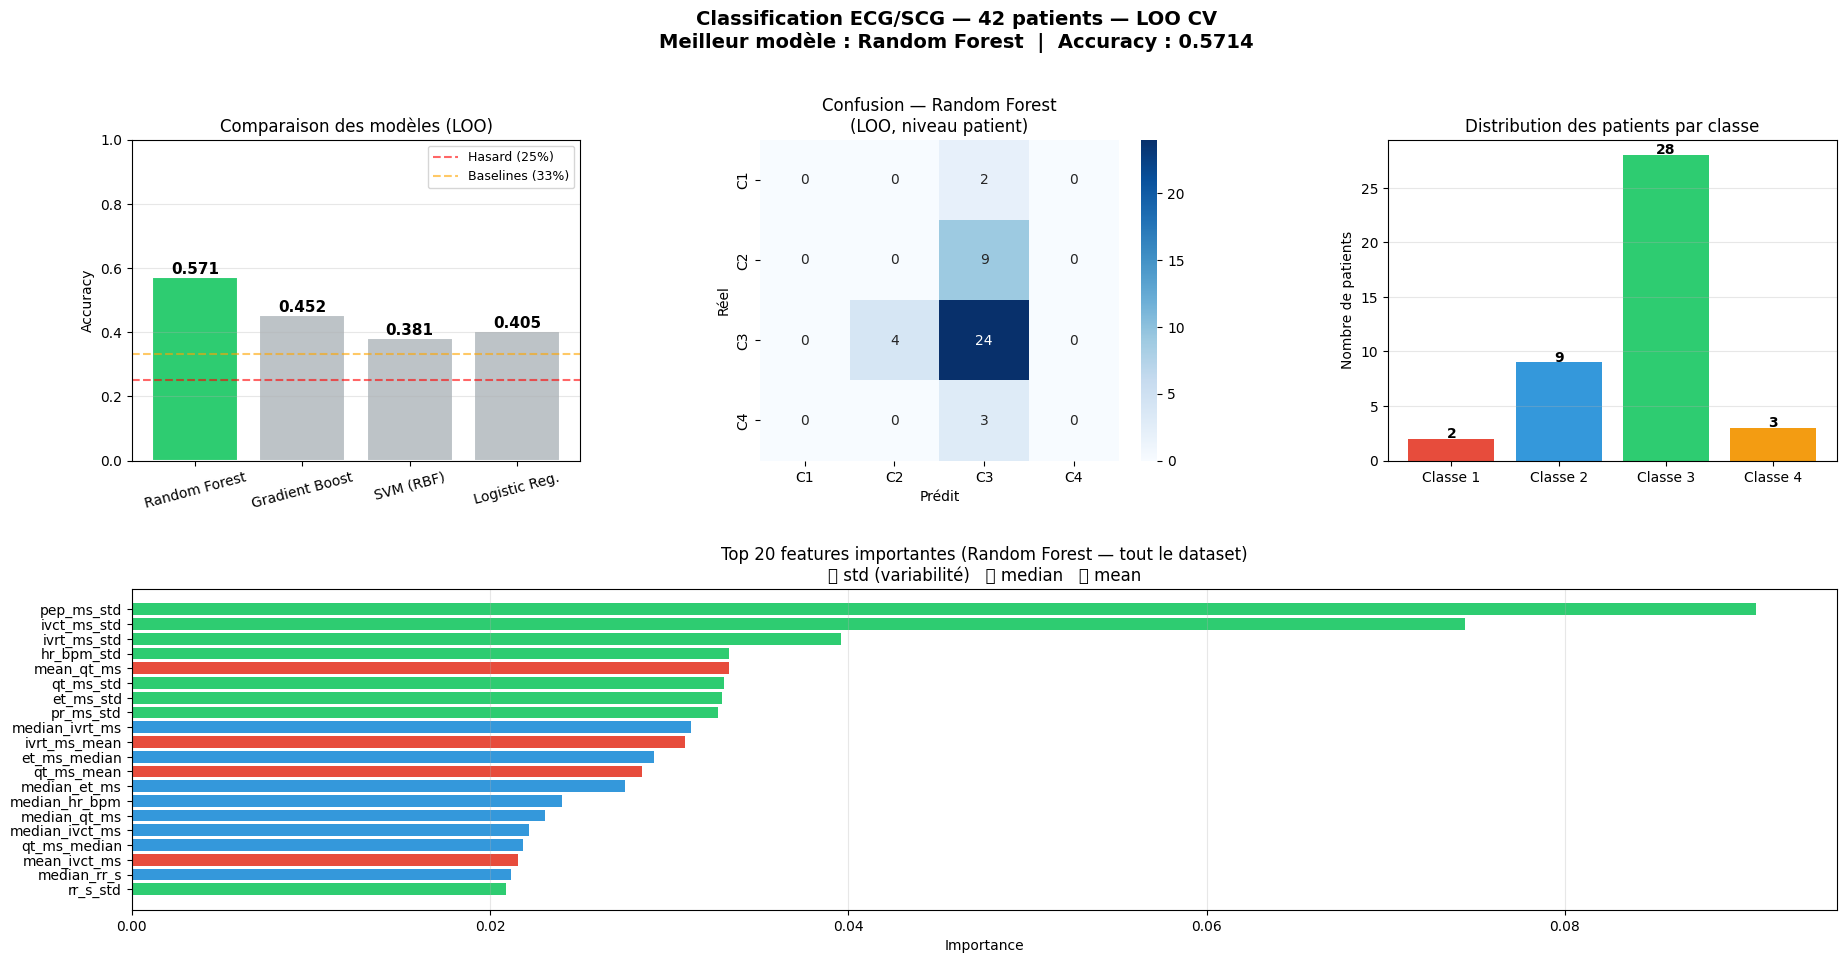


Graphiques sauvegardés : resultats_patient_loo.png


In [ ]:
"""
Modèle de classification ECG/SCG — Split par patient + LOO
═══════════════════════════════════════════════════════════
Contexte :
  - 42 patients (2 en classe 1, 9 en classe 2, 28 en classe 3, 3 en classe 4)
  - Split STRICT par patient : aucun patient ne chevauche train et test
  - Agrégation au niveau patient (mean + std + median des battements)
  - Leave-One-Out CV : seule évaluation fiable avec si peu de patients
  - 4 modèles comparés, meilleur sélectionné automatiquement
"""

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ══════════════════════════════════════════════════════════════════════════════
# 1. CHARGEMENT
# ══════════════════════════════════════════════════════════════════════════════
df = pd.read_csv("ecg_scg_segment_dataset.csv")
print(f"Shape original         : {df.shape}")
print(f"Patients               : {df['patient_id'].nunique()}")
print(f"Segments               : {df['segment_name'].nunique()}")

# ══════════════════════════════════════════════════════════════════════════════
# 2. NETTOYAGE
# ══════════════════════════════════════════════════════════════════════════════

# a) Lignes sans classe cible
df = df.dropna(subset=["classe"])

# b) beat_index == 0 : premier battement sans RR/HR (pas de battement précédent)
df = df[df["beat_index"] != 0]

# c) Imputation intelligente : ivrt_ms NaN → valeur médiane du segment (déjà calculée)
#    On utilise median_ivrt_ms qui est toujours disponible
df.loc[df["ivrt_ms"].isna(), "ivrt_ms"] = df.loc[df["ivrt_ms"].isna(), "median_ivrt_ms"]

# d) Supprimer les quelques NaN restants (qt_ms, pep_ms, et_ms, ivct_ms → <1%)
df = df.dropna()

print(f"Shape après nettoyage  : {df.shape}")
print(f"NaN restants           : {df.isnull().sum().sum()}")

# ══════════════════════════════════════════════════════════════════════════════
# 3. AGRÉGATION AU NIVEAU PATIENT
#    Chaque patient → 1 ligne résumant l'ensemble de ses battements
#    Features battement : mean + std + median (capturent variabilité intra-patient)
#    Features segment   : moyennées sur tous les segments du patient
# ══════════════════════════════════════════════════════════════════════════════
BEAT_FEATS = [
    "pr_ms", "qt_ms", "rr_s", "hr_bpm",
    "pep_ms", "et_ms", "ivct_ms", "ivrt_ms",
]
SEG_FEATS = [
    "mean_pr_ms", "median_pr_ms", "mean_qt_ms", "median_qt_ms",
    "mean_rr_s",  "median_rr_s",  "mean_hr_bpm", "median_hr_bpm",
    "mean_pep_ms","median_pep_ms","mean_et_ms",  "median_et_ms",
    "mean_ivct_ms","median_ivct_ms","mean_ivrt_ms","median_ivrt_ms",
]

agg_dict = {}
for f in BEAT_FEATS:
    agg_dict[f"{f}_mean"]   = (f, "mean")
    agg_dict[f"{f}_std"]    = (f, "std")
    agg_dict[f"{f}_median"] = (f, "median")
for f in SEG_FEATS:
    agg_dict[f] = (f, "mean")

patient_df = (
    df.groupby(["patient_id", "classe"])
    .agg(**agg_dict)
    .reset_index()
    .fillna(0)  # std=0 si un seul segment
)

FEAT_COLS = [c for c in patient_df.columns if c not in ["patient_id", "classe"]]
X        = patient_df[FEAT_COLS].values
y        = patient_df["classe"].astype(int).values
patients = patient_df["patient_id"].values

print(f"\nDataset patient-level  : {len(y)} patients × {len(FEAT_COLS)} features")
print("\nDistribution des classes :")
for cls, cnt in zip(*np.unique(y, return_counts=True)):
    bar = "█" * cnt
    print(f"  Classe {cls} : {cnt:2d} patients  {bar}")

# ══════════════════════════════════════════════════════════════════════════════
# 4. MODÈLES + LEAVE-ONE-OUT CROSS-VALIDATION
#    LOO = seule évaluation fiable avec 42 patients
#    Chaque fold : train sur 41 patients, test sur 1
# ══════════════════════════════════════════════════════════════════════════════
loo = LeaveOneOut()

models = {
    "Random Forest" : RandomForestClassifier(
        n_estimators=500, max_depth=5,
        class_weight="balanced", random_state=42
    ),
    "Gradient Boost" : GradientBoostingClassifier(
        n_estimators=100, max_depth=3,
        learning_rate=0.05, random_state=42
    ),
    "SVM (RBF)" : Pipeline([
        ("scaler", StandardScaler()),
        ("svm",    SVC(C=1.0, kernel="rbf", class_weight="balanced", random_state=42)),
    ]),
    "Logistic Reg." : Pipeline([
        ("scaler", StandardScaler()),
        ("lr",     LogisticRegression(
            C=0.5, max_iter=1000,
            class_weight="balanced",

            random_state=42
        )),
    ]),
}

print(f"\n{'═'*55}")
print(f"  ÉVALUATION LOO — {len(y)} patients, {len(y)} folds")
print(f"{'═'*55}")

results     = {}
best_name   = None
best_acc    = 0.0
best_preds  = None

for name, model in models.items():
    preds = cross_val_predict(model, X, y, cv=loo)
    acc   = (preds == y).mean()
    results[name] = {"acc": acc, "preds": preds}
    flag = "  ← meilleur" if acc > best_acc else ""
    print(f"  {name:<18} : {acc:.4f}  ({(preds==y).sum()}/{len(y)} corrects){flag}")
    if acc > best_acc:
        best_acc, best_name, best_preds = acc, name, preds

print(f"{'═'*55}\n")

# ══════════════════════════════════════════════════════════════════════════════
# 5. RAPPORT DÉTAILLÉ DU MEILLEUR MODÈLE
# ══════════════════════════════════════════════════════════════════════════════
print(f"Meilleur modèle : {best_name}  (accuracy LOO = {best_acc:.4f})\n")
print(classification_report(
    y, best_preds,
    target_names=["Classe 1", "Classe 2", "Classe 3", "Classe 4"],
    zero_division=0
))

print(f"\n{'Patient':<30} {'Réel':>6} {'Prédit':>7}  {'':>4}")
print("─" * 52)
for pat, true, pred in zip(patients, y, best_preds):
    status = "✅" if true == pred else "❌"
    print(f"{pat:<30} {true:>6} {pred:>7}   {status}")

# ══════════════════════════════════════════════════════════════════════════════
# 6. IMPORTANCE DES FEATURES
# ══════════════════════════════════════════════════════════════════════════════
rf_full = RandomForestClassifier(
    n_estimators=500, max_depth=5,
    class_weight="balanced", random_state=42
)
rf_full.fit(X, y)
importance = (
    pd.Series(rf_full.feature_importances_, index=FEAT_COLS)
    .sort_values(ascending=False)
)

# ══════════════════════════════════════════════════════════════════════════════
# 7. VISUALISATIONS
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(22, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.4)

# ── Comparaison des modèles (haut gauche)
ax0 = fig.add_subplot(gs[0, 0])
names_list = list(results.keys())
accs_list  = [results[n]["acc"] for n in names_list]
colors     = ["#2ecc71" if n == best_name else "#bdc3c7" for n in names_list]
bars = ax0.bar(names_list, accs_list, color=colors, edgecolor="white", linewidth=1.5)
ax0.axhline(1/4, color="red", linestyle="--", alpha=0.6, label="Hasard (25%)")
ax0.axhline(1/3, color="orange", linestyle="--", alpha=0.6, label="Baselines (33%)")
for bar, acc in zip(bars, accs_list):
    ax0.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{acc:.3f}", ha="center", fontsize=11, fontweight="bold")
ax0.set_ylim(0, 1); ax0.set_title("Comparaison des modèles (LOO)", fontsize=12)
ax0.set_ylabel("Accuracy"); ax0.legend(fontsize=9); ax0.grid(axis="y", alpha=0.3)
ax0.tick_params(axis="x", rotation=15)

# ── Matrice de confusion meilleur modèle (haut centre)
ax1 = fig.add_subplot(gs[0, 1])
cm = confusion_matrix(y, best_preds, labels=[1, 2, 3, 4])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax1,
            xticklabels=["C1","C2","C3","C4"],
            yticklabels=["C1","C2","C3","C4"])
ax1.set_title(f"Confusion — {best_name}\n(LOO, niveau patient)", fontsize=12)
ax1.set_xlabel("Prédit"); ax1.set_ylabel("Réel")

# ── Distribution des classes (haut droite)
ax2 = fig.add_subplot(gs[0, 2])
cls_labels = [f"Classe {c}" for c in np.unique(y)]
cls_counts = [np.sum(y == c) for c in np.unique(y)]
ax2.bar(cls_labels, cls_counts, color=["#e74c3c","#3498db","#2ecc71","#f39c12"])
for i, (lbl, cnt) in enumerate(zip(cls_labels, cls_counts)):
    ax2.text(i, cnt + 0.1, str(cnt), ha="center", fontweight="bold")
ax2.set_title("Distribution des patients par classe", fontsize=12)
ax2.set_ylabel("Nombre de patients"); ax2.grid(axis="y", alpha=0.3)

# # ── Top 20 features importantes (bas, large)
# ax3 = fig.add_subplot(gs[1, :])
# top20 = importance.head(20)
# colors_feat = ["#2ecc71" if "std" in f else "#3498db" if "median" in f else "#e74c3c"
#                for f in top20.index]
# ax3.barh(top20.index[::-1], top20.values[::-1], color=colors_feat[::-1])
# ax3.set_title("Top 20 features importantes (Random Forest — tout le dataset)\n"
#               "🟢 std (variabilité)   🔵 median   🔴 mean", fontsize=12)
# ax3.set_xlabel("Importance"); ax3.grid(axis="x", alpha=0.3)

# plt.suptitle(f"Classification ECG/SCG — {len(y)} patients — LOO CV\n"
#              f"Meilleur modèle : {best_name}  |  Accuracy : {best_acc:.4f}",
#              fontsize=14, fontweight="bold", y=1.01)

plt.savefig("resultats_patient_loo.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nGraphiques sauvegardés : resultats_patient_loo.png")